In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset using your exact file path
df = pd.read_csv(r"C:\Users\DELL\Downloads\Oasis_Infobyte_Projects\Advertising[1].csv")

# Drop the 'Unnamed: 0' column if it exists in the dataset
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print("--- CLEANED DATASET PREVIEW ---")
print(df.head())
print("\n--- MISSING VALUES CHECK ---")
print(df.isnull().sum())

--- CLEANED DATASET PREVIEW ---
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

--- MISSING VALUES CHECK ---
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Separate features (X) and target variable (y)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate professional metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("--- MODEL PERFORMANCE EVALUATION ---")
print(f"R-squared Score (Model Accuracy): {r2 * 100:.2f}%")
print(f"Mean Absolute Error: {mae:.2f} Units")

--- MODEL PERFORMANCE EVALUATION ---
R-squared Score (Model Accuracy): 89.94%
Mean Absolute Error: 1.46 Units


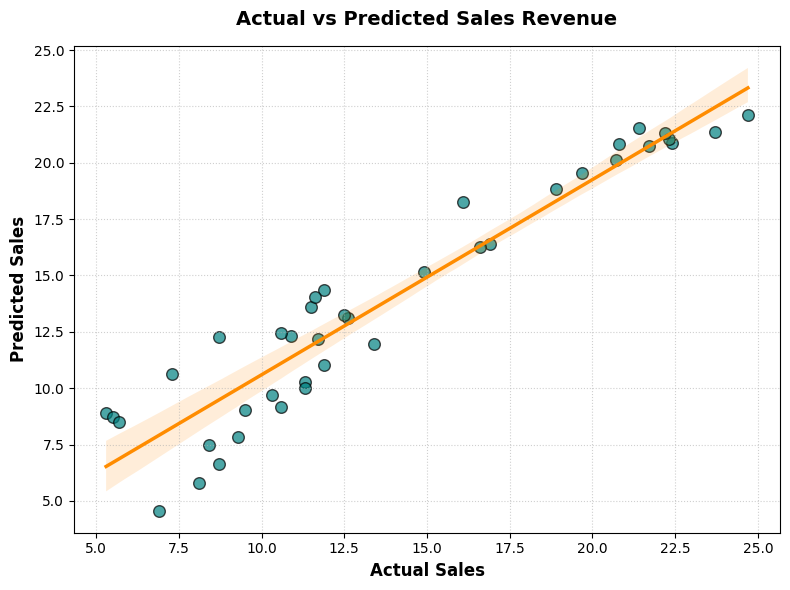

In [4]:
# Create a professional scatter plot with a regression fit line
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_pred, color='teal', 
            scatter_kws={'alpha':0.7, 'edgecolor':'black', 's':70},
            line_kws={'color':'darkorange', 'lw':2.5})

plt.title('Actual vs Predicted Sales Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Sales', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Sales', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()